# COM7019 — Artificial Intelligence and Neural Networks
## Task 1: Stock Market Prediction using LSTM and GRU

**Dataset:** `Stock_Price_Data__3921_.csv`  
**Target:** Predict daily closing price using historical sequences  
**Models:** Long Short-Term Memory (LSTM) vs Gated Recurrent Unit (GRU)

---

## Step 1 — Install & Import Libraries

We import all required libraries upfront:
- `numpy` / `pandas` — data handling
- `matplotlib` — visualisations
- `sklearn` — preprocessing and evaluation metrics
- `tensorflow / keras` — building and training the neural network models

In [1]:
# Install required packages (run once — remove if already installed)
# !pip install tensorflow scikit-learn matplotlib pandas numpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

# Set seeds so results are reproducible every run
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully.")

TensorFlow version: 2.20.0
All libraries imported successfully.


---
## Step 2 — Load and Explore the Dataset

We load the CSV file and do a basic exploration to understand:
- How many rows and columns we have
- The date range covered
- Whether any values are missing

In [2]:
# Load the dataset
df = pd.read_csv('Stock_Price_Data_[3921].csv')

# Convert the Date column to a proper datetime type and sort chronologically
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Basic exploration
print("Shape:", df.shape)
print("Date range:", df['Date'].iloc[0].date(), "→", df['Date'].iloc[-1].date())
print("\nFirst 5 rows:")
display(df.head())

print("\nMissing values per column:")
print(df.isnull().sum())

Shape: (9909, 7)
Date range: 1980-12-12 → 2020-04-01

First 5 rows:


,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400



Missing values per column:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [3]:
# Statistical summary of the numeric columns
print("Statistical Summary:")
display(df[['Open', 'High', 'Low', 'Close', 'Volume']].describe().round(2))

Statistical Summary:


,Open,High,Low,Close,Volume
count,9909.00,9909.00,9909.00,9909.00,9.909000e+03
mean,32.61,32.94,32.28,32.62,8.582916e+07
std,58.42,59.00,57.88,58.47,8.597195e+07
min,0.20,0.20,0.20,0.20,3.472000e+05
25%,1.07,1.09,1.05,1.07,3.304230e+07
50%,1.73,1.76,1.70,1.73,5.766490e+07
75%,35.80,36.27,35.33,35.76,1.069992e+08
max,324.74,327.85,323.35,327.20,1.855410e+09


In [4]:
# checking for diplucatoion
df.duplicated().sum()


np.int64(0)

---
## Step 3 — Visualise the Raw Data

Before building any model, we always visualise the data to spot:
- Overall price trends
- Volatility patterns
- Volume behaviour over time

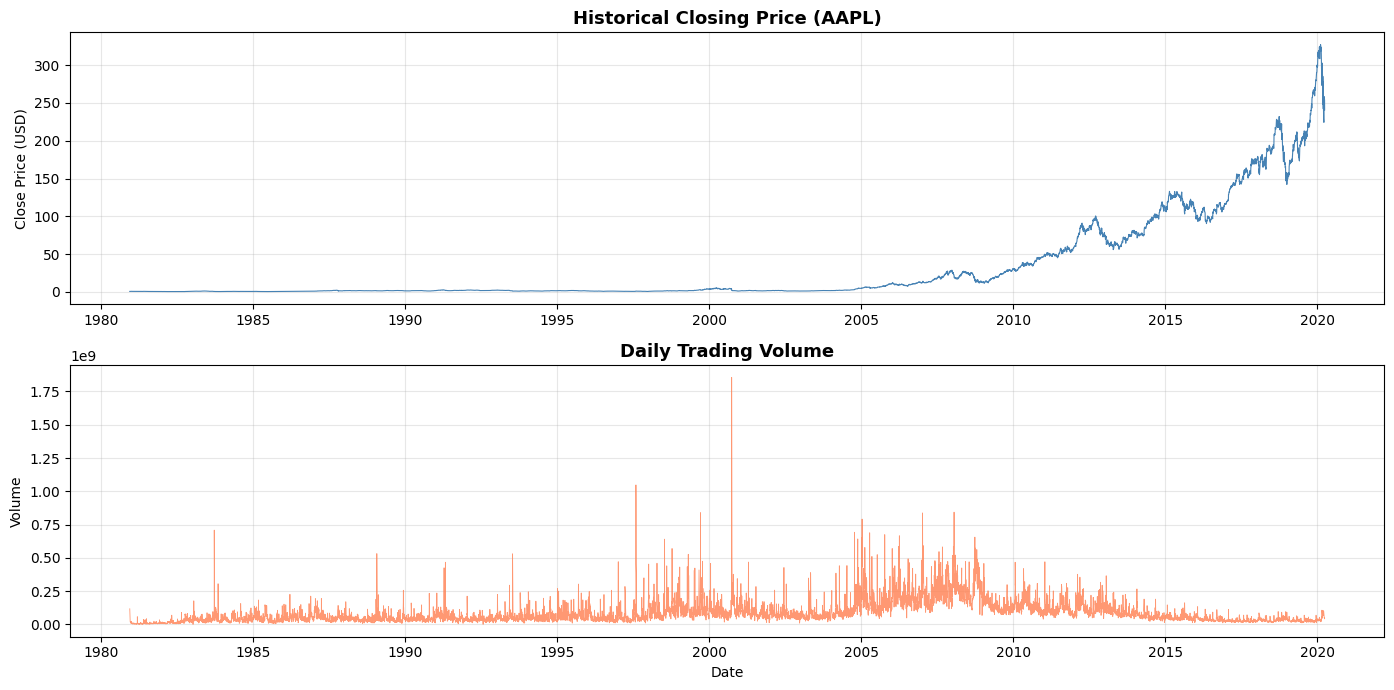

Saved: 01_raw_data.png


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Plot 1 — Closing price over time
axes[0].plot(df['Date'], df['Close'], color='steelblue', linewidth=0.8)
axes[0].set_title('Historical Closing Price (AAPL)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Close Price (USD)')
axes[0].grid(True, alpha=0.3)

# Plot 2 — Trading volume over time
axes[1].plot(df['Date'], df['Volume'], color='coral', linewidth=0.6, alpha=0.8)
axes[1].set_title('Daily Trading Volume', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Volume')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_raw_data.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 01_raw_data.png")

---
## Step 4 — Preprocess the Data

### 4a — Select the target feature
We use the **Close** price as our prediction target — the most common choice for stock prediction tasks.

### 4b — Normalise with MinMaxScaler
LSTM and GRU use sigmoid and tanh activation functions internally, which saturate on large values.  
Scaling all values to the range **[0, 1]** ensures stable and efficient training.

### 4c — Train / Test split
We split **80% train / 20% test** — crucially, **without shuffling**, because order matters in time series.

### 4d — Create sequences (sliding window)
Both models expect sequences as input, not individual values.  
We use a **lookback window of 60 days**: each sample contains 60 past closing prices, and the label is day 61.

In [6]:
# ── 4a: Select target feature ──────────────────────────────────────────────
data = df['Close'].values.reshape(-1, 1)
print(f"Total data points: {len(data)}")

# ── 4b: Normalise to [0, 1] ────────────────────────────────────────────────
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)
print(f"Min scaled value: {data_scaled.min():.4f}")
print(f"Max scaled value: {data_scaled.max():.4f}")

Total data points: 9909
Min scaled value: 0.0000
Max scaled value: 1.0000


In [7]:
# ── 4c: Train / Test split (80 / 20, no shuffling) ─────────────────────────
train_size = int(len(data_scaled) * 0.80)
train_data = data_scaled[:train_size]
test_data  = data_scaled[train_size:]

print(f"Training samples : {len(train_data)}  ({len(train_data)/len(data_scaled)*100:.0f}%)")
print(f"Testing  samples : {len(test_data)}   ({len(test_data)/len(data_scaled)*100:.0f}%)")

Training samples : 7927  (80%)
Testing  samples : 1982   (20%)


In [8]:
# ── 4d: Build sequences using a sliding window ─────────────────────────────
SEQUENCE_LENGTH = 60   # use 60 past days to predict day 61

def create_sequences(dataset, seq_length):
    """
    Converts 1D time-series into supervised learning sequences.
    X[i] = seq_length consecutive values
    y[i] = the value immediately after that window
    """
    X, y = [], []
    for i in range(seq_length, len(dataset)):
        X.append(dataset[i - seq_length:i, 0])  # window of past values
        y.append(dataset[i, 0])                  # next value to predict
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_data, SEQUENCE_LENGTH)
X_test,  y_test  = create_sequences(test_data,  SEQUENCE_LENGTH)

# Keras expects shape: [samples, timesteps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0],   X_test.shape[1],  1))

print(f"X_train shape : {X_train.shape}  → (samples, timesteps, features)")
print(f"X_test  shape : {X_test.shape}")
print(f"y_train shape : {y_train.shape}")

X_train shape : (7867, 60, 1)  → (samples, timesteps, features)
X_test  shape : (1922, 60, 1)
y_train shape : (7867,)


---
## Step 5 — Build the LSTM Model

### Architecture choices:
| Layer | Units | Why |
|---|---|---|
| LSTM (1) | 100 | Captures complex long-term dependencies in the sequence |
| Dropout | 20% | Randomly deactivates neurons during training to prevent overfitting |
| LSTM (2) | 50 | Refines features from the first layer |
| Dropout | 20% | Second regularisation layer |
| Dense | 25 | Small fully-connected layer for non-linear combination |
| Dense (output) | 1 | Single predicted price value |

`return_sequences=True` on the first LSTM means it passes its full output sequence to the next LSTM layer (required for stacking).  
`return_sequences=False` on the second means it only outputs the final timestep.

In [9]:
def build_lstm(seq_length):
    model = Sequential([
        LSTM(100, return_sequences=True, input_shape=(seq_length, 1)),
        Dropout(0.2),
        LSTM(50, return_sequences=False),
        Dropout(0.2),
        Dense(25, activation='relu'),
        Dense(1)
    ], name='LSTM_Model')
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
    return model

lstm_model = build_lstm(SEQUENCE_LENGTH)
lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 100)        │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,301 (282.43 KB)

 Trainable params: 72,301 (282.43 KB)

 Non-trainable params: 0 (0.00 B)

---
## Step 6 — Train the LSTM Model

### EarlyStopping
We use `EarlyStopping` with:
- `monitor='val_loss'` — watches validation loss
- `patience=10` — stops if no improvement for 10 consecutive epochs
- `restore_best_weights=True` — rolls back to the best checkpoint automatically

### Validation split
We hold out **10% of the training data** as a validation set to monitor generalisation during training.

In [10]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

print("Training LSTM model...")
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
print(f"\nLSTM stopped at epoch: {len(lstm_history.history['loss'])}")

Training LSTM model...
Epoch 1/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 1.6158e-05 - mae: 0.0023 - val_loss: 4.6822e-05 - val_mae: 0.0048
Epoch 2/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 6.3338e-06 - mae: 0.0017 - val_loss: 3.7583e-05 - val_mae: 0.0044
Epoch 3/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 4.9532e-06 - mae: 0.0015 - val_loss: 1.3021e-04 - val_mae: 0.0090
Epoch 4/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5.1504e-06 - mae: 0.0015 - val_loss: 2.9269e-05 - val_mae: 0.0039
Epoch 5/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 4.7584e-06 - mae: 0.0014 - val_loss: 8.0177e-05 - val_mae: 0.0069
Epoch 6/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 4.3854e-06 - mae: 0.0014 - val_loss: 7.3936e-05 - val_mae: 0.0064
Epoch 7/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 3.9919e-06 - mae: 0.0013 - val_loss: 6.0641e-05 - val_mae: 0.0056
Epoch 8/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 3.6442e-06 - mae: 0

---
## Step 7 — Build the GRU Model

The GRU architecture mirrors the LSTM exactly — same layer sizes, same dropout rates.  
This is intentional: a **fair comparison** requires both models to be tested under the same conditions.

The only difference is the recurrent unit type itself (GRU vs LSTM).

In [11]:
def build_gru(seq_length):
    model = Sequential([
        GRU(100, return_sequences=True, input_shape=(seq_length, 1)),
        Dropout(0.2),
        GRU(50, return_sequences=False),
        Dropout(0.2),
        Dense(25, activation='relu'),
        Dense(1)
    ], name='GRU_Model')
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
    return model

gru_model = build_gru(SEQUENCE_LENGTH)
gru_model.summary()

Model: "GRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 100)        │        30,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 50)             │        22,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,001 (214.85 KB)

 Trainable params: 55,001 (214.85 KB)

 Non-trainable params: 0 (0.00 B)

---
## Step 8 — Train the GRU Model

In [12]:
print("Training GRU model...")
gru_history = gru_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
print(f"\nGRU stopped at epoch: {len(gru_history.history['loss'])}")

Training GRU model...
Epoch 1/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 2.1816e-05 - mae: 0.0026 - val_loss: 2.0371e-05 - val_mae: 0.0032
Epoch 2/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 6.2845e-06 - mae: 0.0017 - val_loss: 6.2951e-05 - val_mae: 0.0067
Epoch 3/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 6.5005e-06 - mae: 0.0018 - val_loss: 1.6829e-05 - val_mae: 0.0032
Epoch 4/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 6.2166e-06 - mae: 0.0017 - val_loss: 4.1133e-05 - val_mae: 0.0047
Epoch 5/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 4.3019e-06 - mae: 0.0014 - val_loss: 1.7281e-04 - val_mae: 0.0119
Epoch 6/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 4.1449e-06 - mae: 0.0014 - val_loss: 7.2006e-05 - val_mae: 0.0064
Epoch 7/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 3.9217e-06 - mae: 0.0014 - val_loss: 2.5080e-05 - val_mae: 0.0037
Epoch 8/100
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 3.9917e-06 - mae: 0.00

---
## Step 9 — Plot Training & Validation Loss

These curves show how well each model learned over time.  
- **Training loss** decreasing = the model is fitting the data  
- **Validation loss** following closely = the model generalises well (not overfitting)  
- A large gap between the two = overfitting

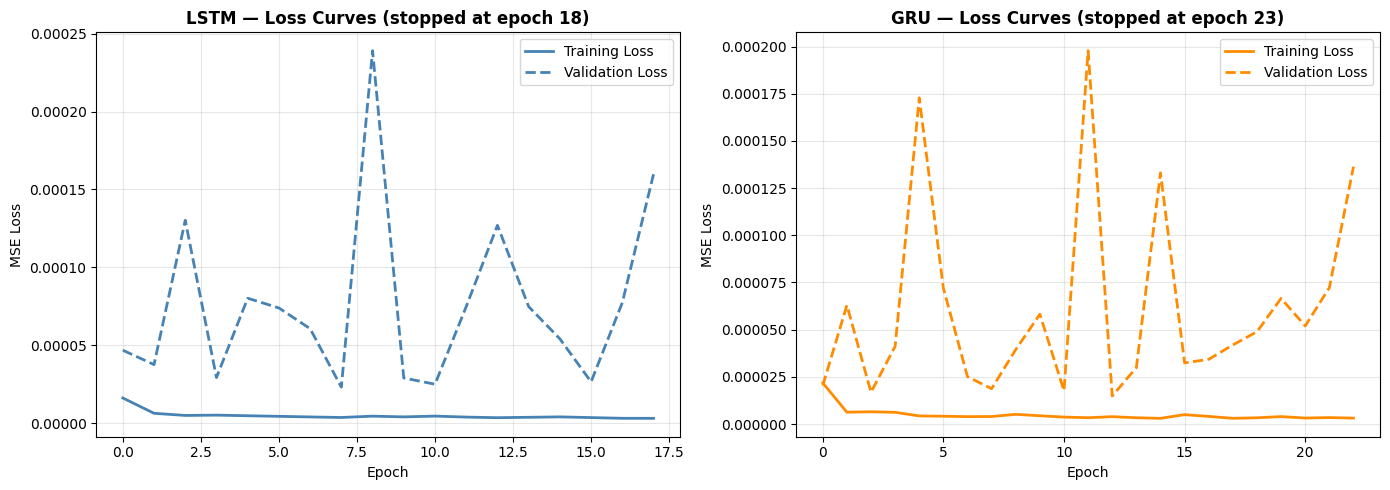

Saved: 02_loss_curves.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, history, name, color in zip(
    axes,
    [lstm_history, gru_history],
    ['LSTM', 'GRU'],
    ['steelblue', 'darkorange']
):
    epochs_ran = len(history.history['loss'])
    ax.plot(history.history['loss'],     label='Training Loss',   color=color, linewidth=2)
    ax.plot(history.history['val_loss'], label='Validation Loss', color=color,
            linestyle='--', linewidth=2)
    ax.set_title(f'{name} — Loss Curves (stopped at epoch {epochs_ran})',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 02_loss_curves.png")

---
## Step 10 — Generate Predictions

We run both models on the test set, then **inverse-transform** the predictions back to the original price scale using the same scaler we fitted in Step 4.

In [14]:
# Generate predictions (still in scaled [0,1] range)
lstm_pred_scaled = lstm_model.predict(X_test, verbose=0)
gru_pred_scaled  = gru_model.predict(X_test,  verbose=0)

# Inverse transform back to USD prices
lstm_pred = scaler.inverse_transform(lstm_pred_scaled)
gru_pred  = scaler.inverse_transform(gru_pred_scaled)
y_actual  = scaler.inverse_transform(y_test.reshape(-1, 1))

print(f"Predictions shape : {lstm_pred.shape}")
print(f"Actual values shape: {y_actual.shape}")
print(f"\nSample — Actual: ${y_actual[0,0]:.2f} | LSTM: ${lstm_pred[0,0]:.2f} | GRU: ${gru_pred[0,0]:.2f}")

Predictions shape : (1922, 1)
Actual values shape: (1922, 1)

Sample — Actual: $88.81 | LSTM: $87.17 | GRU: $86.98


---
## Step 11 — Evaluate Model Performance

We use four complementary metrics:

| Metric | Measures | Ideal |
|---|---|---|
| **MAE** (Mean Absolute Error) | Average absolute error in USD | As low as possible |
| **RMSE** (Root Mean Squared Error) | Error penalising large mistakes more | As low as possible |
| **R²** (Coefficient of Determination) | Proportion of variance explained | As close to 1.0 as possible |
| **MAPE** (Mean Absolute Percentage Error) | Average % error — scale-independent | As low as possible |

In [15]:
def evaluate_model(name, actual, predicted):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2   = r2_score(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f"{'─'*45}")
    print(f"  {name}")
    print(f"{'─'*45}")
    print(f"  MAE   (Mean Absolute Error)      : ${mae:.4f}")
    print(f"  RMSE  (Root Mean Squared Error)  : ${rmse:.4f}")
    print(f"  R²    (Coefficient of Determination): {r2:.4f}")
    print(f"  MAPE  (Mean Abs. Percentage Error): {mape:.2f}%")
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

lstm_metrics = evaluate_model("LSTM", y_actual, lstm_pred)
print()
gru_metrics  = evaluate_model("GRU",  y_actual, gru_pred)

─────────────────────────────────────────────
  LSTM
─────────────────────────────────────────────
  MAE   (Mean Absolute Error)      : $5.8106
  RMSE  (Root Mean Squared Error)  : $8.7465
  R²    (Coefficient of Determination): 0.9772
  MAPE  (Mean Abs. Percentage Error): 3.61%

─────────────────────────────────────────────
  GRU
─────────────────────────────────────────────
  MAE   (Mean Absolute Error)      : $5.1116
  RMSE  (Root Mean Squared Error)  : $7.1777
  R²    (Coefficient of Determination): 0.9846
  MAPE  (Mean Abs. Percentage Error): 3.27%


---
## Step 12 — Plot Actual vs Predicted Prices

This is the most intuitive way to assess model quality — if the predicted line closely tracks the actual line across the test period, the model is performing well.

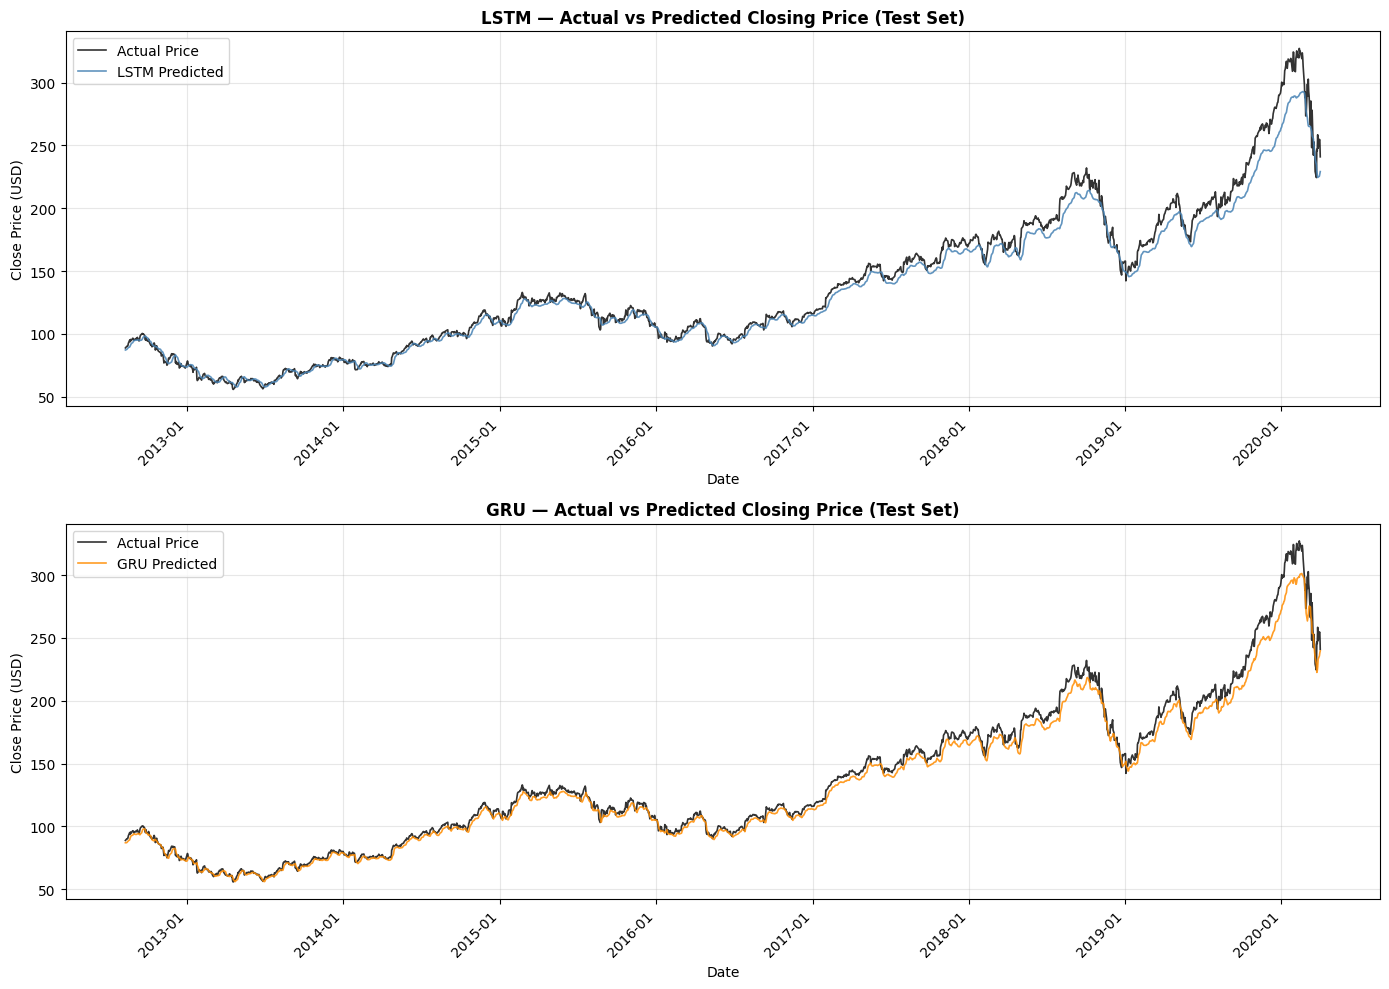

Saved: 03_actual_vs_predicted.png


In [16]:
# Get the dates that correspond to the test set predictions
test_dates = df['Date'].iloc[train_size + SEQUENCE_LENGTH:].reset_index(drop=True)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for ax, pred, name, color in zip(
    axes,
    [lstm_pred, gru_pred],
    ['LSTM', 'GRU'],
    ['steelblue', 'darkorange']
):
    ax.plot(test_dates, y_actual, label='Actual Price',
            color='black', linewidth=1.2, alpha=0.8)
    ax.plot(test_dates, pred, label=f'{name} Predicted',
            color=color, linewidth=1.2, alpha=0.85)
    ax.set_title(f'{name} — Actual vs Predicted Closing Price (Test Set)',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Close Price (USD)')
    ax.set_xlabel('Date')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('03_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 03_actual_vs_predicted.png")

---
## Step 13 — Compare Metrics with Bar Charts

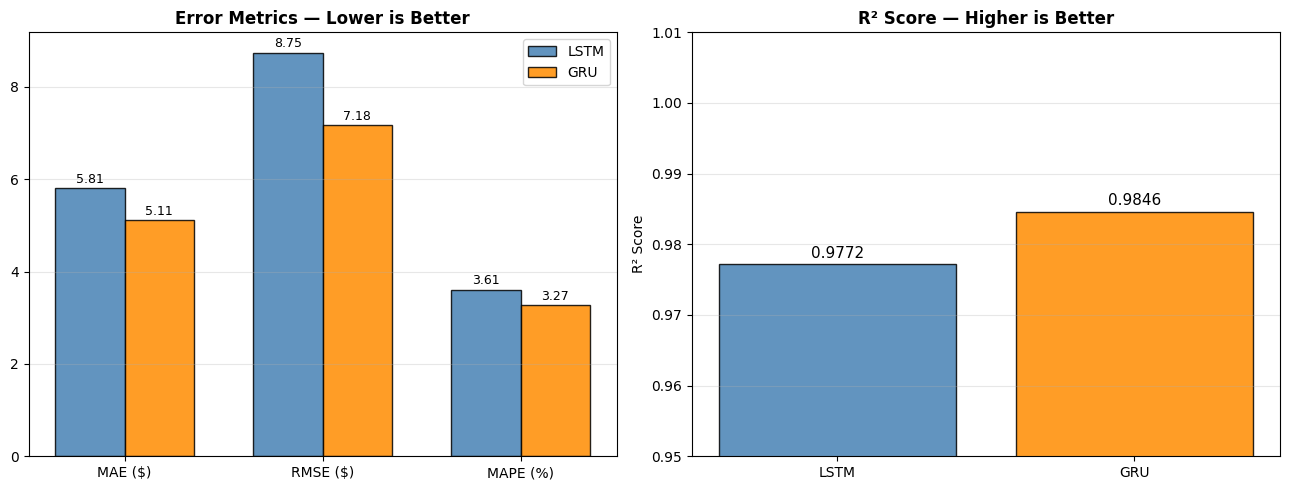

Saved: 04_metrics_comparison.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Chart 1: Error metrics (lower is better) ──────────────────────────────
metrics_labels = ['MAE ($)', 'RMSE ($)', 'MAPE (%)']
lstm_vals = [lstm_metrics['MAE'], lstm_metrics['RMSE'], lstm_metrics['MAPE']]
gru_vals  = [gru_metrics['MAE'],  gru_metrics['RMSE'],  gru_metrics['MAPE']]
x = np.arange(len(metrics_labels))
w = 0.35

b1 = axes[0].bar(x - w/2, lstm_vals, w, label='LSTM', color='steelblue',
                  alpha=0.85, edgecolor='black')
b2 = axes[0].bar(x + w/2, gru_vals,  w, label='GRU',  color='darkorange',
                  alpha=0.85, edgecolor='black')
axes[0].set_title('Error Metrics — Lower is Better', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_labels)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

for bar in b1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                  f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
for bar in b2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                  f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

# ── Chart 2: R² Score (higher is better) ──────────────────────────────────
r2_vals = [lstm_metrics['R2'], gru_metrics['R2']]
bars = axes[1].bar(['LSTM', 'GRU'], r2_vals,
                    color=['steelblue', 'darkorange'], alpha=0.85, edgecolor='black')
axes[1].set_title('R² Score — Higher is Better', fontsize=12, fontweight='bold')
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(0.95, 1.01)
axes[1].grid(True, alpha=0.3, axis='y')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                  f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('04_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 04_metrics_comparison.png")

---
## Step 14 — Final Summary Table

In [18]:
summary = pd.DataFrame({
    'Metric': [
        'MAE ($)',
        'RMSE ($)',
        'R² Score',
        'MAPE (%)',
        'Epochs run',
        'Total parameters'
    ],
    'LSTM': [
        f"{lstm_metrics['MAE']:.4f}",
        f"{lstm_metrics['RMSE']:.4f}",
        f"{lstm_metrics['R2']:.4f}",
        f"{lstm_metrics['MAPE']:.2f}%",
        len(lstm_history.history['loss']),
        lstm_model.count_params()
    ],
    'GRU': [
        f"{gru_metrics['MAE']:.4f}",
        f"{gru_metrics['RMSE']:.4f}",
        f"{gru_metrics['R2']:.4f}",
        f"{gru_metrics['MAPE']:.2f}%",
        len(gru_history.history['loss']),
        gru_model.count_params()
    ]
})

display(summary)

# Determine winner per metric
print("\n--- Winner per metric ---")
for m in ['MAE', 'RMSE', 'MAPE']:
    winner = 'GRU' if gru_metrics[m] < lstm_metrics[m] else 'LSTM'
    print(f"  {m:6s}: {winner} wins (lower is better)")
winner_r2 = 'GRU' if gru_metrics['R2'] > lstm_metrics['R2'] else 'LSTM'
print(f"  R²    : {winner_r2} wins (higher is better)")

,Metric,LSTM,GRU
0,MAE ($),5.8106,5.1116
1,RMSE ($),8.7465,7.1777
2,R² Score,0.9772,0.9846
3,MAPE (%),3.61%,3.27%
4,Epochs run,18,23
5,Total parameters,72301,55001



--- Winner per metric ---
  MAE   : GRU wins (lower is better)
  RMSE  : GRU wins (lower is better)
  MAPE  : GRU wins (lower is better)
  R²    : GRU wins (higher is better)
